In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
import pandas as pd
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Business_Case_Retail-Sales/customer_shopping_behavior.csv')

df.head()

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Payment Method,Frequency of Purchases
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Express,Yes,Yes,14,Venmo,Fortnightly
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Express,Yes,Yes,2,Cash,Fortnightly
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Yes,Free Shipping,Yes,Yes,23,Credit Card,Weekly
3,4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.5,Yes,Next Day Air,Yes,Yes,49,PayPal,Weekly
4,5,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.7,Yes,Free Shipping,Yes,Yes,31,PayPal,Annually


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3900 entries, 0 to 3899
Data columns (total 18 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Customer ID             3900 non-null   int64  
 1   Age                     3900 non-null   int64  
 2   Gender                  3900 non-null   object 
 3   Item Purchased          3900 non-null   object 
 4   Category                3900 non-null   object 
 5   Purchase Amount (USD)   3900 non-null   int64  
 6   Location                3900 non-null   object 
 7   Size                    3900 non-null   object 
 8   Color                   3900 non-null   object 
 9   Season                  3900 non-null   object 
 10  Review Rating           3863 non-null   float64
 11  Subscription Status     3900 non-null   object 
 12  Shipping Type           3900 non-null   object 
 13  Discount Applied        3900 non-null   object 
 14  Promo Code Used         3900 non-null   

describe "all" to get the summarize of both, numerical and categorical values

In [5]:
df.describe(include='all')

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Payment Method,Frequency of Purchases
count,3900.000000,3900.000000,3900,3900,3900,3900.000000,3900,3900,3900,3900,3863.000000,3900,3900,3900,3900,3900.000000,3900,3900
unique,NaN,NaN,2,25,4,NaN,50,4,25,4,NaN,2,6,2,2,NaN,6,7
top,NaN,NaN,Male,Blouse,Clothing,NaN,Montana,M,Olive,Spring,NaN,No,Free Shipping,No,No,NaN,PayPal,Every 3 Months
freq,NaN,NaN,2652,171,1737,NaN,96,1755,177,999,NaN,2847,675,2223,2223,NaN,677,584
mean,1950.500000,44.068462,NaN,NaN,NaN,59.764359,NaN,NaN,NaN,NaN,3.750065,NaN,NaN,NaN,NaN,25.351538,NaN,NaN
std,1125.977353,15.207589,NaN,NaN,NaN,23.685392,NaN,NaN,NaN,NaN,0.716983,NaN,NaN,NaN,NaN,14.447125,NaN,NaN
min,1.000000,18.000000,NaN,NaN,NaN,20.000000,NaN,NaN,NaN,NaN,2.500000,NaN,NaN,NaN,NaN,1.000000,NaN,NaN
25%,975.750000,31.000000,NaN,NaN,NaN,39.000000,NaN,NaN,NaN,NaN,3.100000,NaN,NaN,NaN,NaN,13.000000,NaN,NaN
50%,1950.500000,44.000000,NaN,NaN,NaN,60.000000,NaN,NaN,NaN,NaN,3.800000,NaN,NaN,NaN,NaN,25.000000,NaN,NaN
75%,2925.250000,57.000000,NaN,NaN,NaN,81.000000,NaN,NaN,NaN,NaN,4.400000,NaN,NaN,NaN,NaN,38.000000,NaN,NaN


Let's check if there is any "null" values

In [6]:
df.isnull().sum()

,0
Customer ID,0
Age,0
Gender,0
Item Purchased,0
Category,0
Purchase Amount (USD),0
Location,0
Size,0
Color,0
Season,0


Column 'Review Rating' has nulls. To replace them I'm going to use the the median within each category. It is important to notice that I am not usong the overall median value because this is affected by outliers whereas the category one do not have this bias.

In [7]:
df['Review Rating'] = df.groupby('Category')['Review Rating'].transform(lambda x: x.fillna(x.median()))

In [8]:
df.isnull().sum()

,0
Customer ID,0
Age,0
Gender,0
Item Purchased,0
Category,0
Purchase Amount (USD),0
Location,0
Size,0
Color,0
Season,0


I will modify all column's names into lowercase separeted by underscores

In [9]:
df.columns = df.columns.str.lower()
df.columns = df.columns.str.replace(' ','_')
df = df.rename(columns={'purchase_amount_(usd)':'purchase_amount'})

In [10]:
df.columns

Index(['customer_id', 'age', 'gender', 'item_purchased', 'category',
       'purchase_amount', 'location', 'size', 'color', 'season',
       'review_rating', 'subscription_status', 'shipping_type',
       'discount_applied', 'promo_code_used', 'previous_purchases',
       'payment_method', 'frequency_of_purchases'],
      dtype='object')

In [11]:
#create a column 'age_group'


In [12]:
labels = ['Young Adult', 'Adult', 'Middle-Aged', 'Senior']
df['age_group'] = pd.qcut(df['age'], q=4, labels= labels)

In [13]:
df[['age','age_group']].head()

,age,age_group
0,55,Middle-Aged
1,19,Young Adult
2,50,Middle-Aged
3,21,Young Adult
4,45,Middle-Aged


In [14]:
df['frequency_of_purchases'].head()

,frequency_of_purchases
0,Fortnightly
1,Fortnightly
2,Weekly
3,Weekly
4,Annually


In [15]:
#Let's create column purchase_frequency_days
#first create a dictionary that maps each frequency in number of days in the column

frequency_mapping = {
'Fortnightly':14,
'Weekly':7,
'Monthly':30,
'Quarterly':90,
'Bi-Weekly':14,
'Annually':365,
'Every 3 Months':90

}

df['purchase_frequency_days'] = df['frequency_of_purchases'].map(frequency_mapping)


In [16]:
df[['purchase_frequency_days','frequency_of_purchases']].head(10)

,purchase_frequency_days,frequency_of_purchases
0,14,Fortnightly
1,14,Fortnightly
2,7,Weekly
3,7,Weekly
4,365,Annually
5,7,Weekly
6,90,Quarterly
7,7,Weekly
8,365,Annually
9,90,Quarterly


In [17]:
# i am going to check if the columns  'discount_applied' and 'promo_code_used' are equals and i have redundancy.
(df['discount_applied'] == df['promo_code_used']).all()

np.True_

In [18]:
df = df.drop(columns=['promo_code_used'], axis=1)

In [ ]:
pip install psycopg2-binary sqlalchemy

In [ ]:
pip install --upgrade pip

#CREATE AN SQL DATABASE:

 I've created a separated file called "customer_behaviour_queries.sql" where I have created the database and have performed data exploration in MySQL.


In [ ]:
%pip install --upgrade SQLAlchemy

In [22]:
#import sqlalchemy
#print(sqlalchemy.__version__)


In [ ]:
%pip install "SQLAlchemy<2.0"
%pip install pymysql


In [ ]:
#from sqlalchemy import create_engine

#Mysql connection
username = 'xxxx'
password = 'xxxx'
host = 'xxx.x.x.x'
port= xxxx
database = 'customer_behavior'


engine = create_engine(f'mysql+pymysql://{username}:{password}@{host}:{port}/{database}')

#Write the DataFrame to MySQL
table_name = "customer"
df.to_sql(table_name, con=engine, if_exists="replace", index=False)

#Read the data back from MySQL to verify
pd.read_sql(f'SELECT * FROM customer LIMIT 5', con=engine)


In [ ]:
# Which 5 products have the highest percentage of purchases with discounts applied?

pd.read_sql(
    """
    select subscription_status,
        count(customer_id) AS total_customers,
        round(avg(purchase_amount),2) as avg_spend,
        sum(purchase_amount) as total_revenue
    from customer
    group by subscription_status
    order by total_revenue desc
    """,
    con=engine
)

# **AI Product: Customer Growth Copilot**

User
* Marketing Manager
* CRM Manager
* E-commerce Manager

**Business Problem**

A retailer has 20,000 customers.
Marketing budget is limited.

Who should receive:

- discounts?
- loyalty offers?
- premium memberships?
- reactivation campaigns?

Let's solve the "guessing problem" of most companies

**KPI 1: Customer Health Score**

Based on:

* Previous purchases
* Subscription status
* Average spend
* Discount usage
* Review rating





In [26]:
df.columns

Index(['customer_id', 'age', 'gender', 'item_purchased', 'category',
       'purchase_amount', 'location', 'size', 'color', 'season',
       'review_rating', 'subscription_status', 'shipping_type',
       'discount_applied', 'previous_purchases', 'payment_method',
       'frequency_of_purchases', 'age_group', 'purchase_frequency_days'],
      dtype='object')

In [25]:
#Let's create a sub dataset called 'customer_id' and then calculates the total number of purchases (count), the average purchase amount (mean),
#and the average review_rating for each unique customer.
#This helps to consolidate customer-level information
customer_df = df.groupby('customer_id').agg({
          'age': 'first',
          'gender': 'first',
          'purchase_amount': 'sum',
          'review_rating': 'mean',
          'previous_purchases': 'max',
          'subscription_status': 'first',
          'discount_applied': lambda x: (x == 'Yes').mean() * 100
      })

In [27]:
customer_df.columns = ['_'.join(col).strip() if isinstance(col, tuple) else col for col in customer_df.columns.values]

customer_df.columns = [
    'age',
    'gender',
    'total_spend',
    'avg_rating',
    'previous_purchases',
    'subscription_status',
    'discount_usage_pct'
]

customer_df = customer_df.reset_index()

customer_df.head()

,customer_id,age,gender,total_spend,avg_rating,previous_purchases,subscription_status,discount_usage_pct
0,1,55,Male,53,3.1,14,Yes,100.0
1,2,19,Male,64,3.1,2,Yes,100.0
2,3,50,Male,73,3.1,23,Yes,100.0
3,4,21,Male,90,3.5,49,Yes,100.0
4,5,45,Male,49,2.7,31,Yes,100.0


Customer Health Score (0–100) and create the segments:

* VIP
* Healthy
* At Risk
* Critical



# NORMALIZE COMPONENTS TO 0–100

Each variable lives on a different scale (purchases: 1–50, spend: $20–$100, rating: 2.5–5.0). Normalizing to 0–100 first makes the weighted sum meaningful.

In [28]:

from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt
import seaborn as sns

In [29]:
scaler = MinMaxScaler(feature_range=(0, 100))

customer_df['score_purchases'] = scaler.fit_transform(
    customer_df[['previous_purchases']])

customer_df['score_spend'] = scaler.fit_transform(
    customer_df[['total_spend']])

customer_df['score_rating'] = scaler.fit_transform(
    customer_df[['avg_rating']])

# Subscription: binary 0 or 100
customer_df['score_subscription'] = customer_df['subscription_status'].map(
    {'Yes': 100, 'No': 0})

# Discount usage: INVERTED (lower dependency = healthier)
customer_df['score_discount'] = 100 - customer_df['discount_usage_pct']

In [30]:
# 2. WEIGHTED HEALTH SCORE

weights = {
    'score_purchases':    0.30,
    'score_spend':        0.25,
    'score_rating':       0.20,
    'score_subscription': 0.15,
    'score_discount':     0.10,
}

customer_df['health_score'] = sum(customer_df[col] * w for col, w in weights.items()).round(1)


In [31]:
# 3. SEGMENT LABELS

def assign_segment(score):
    if score >= 75:
        return 'VIP'
    elif score >= 50:
        return 'Healthy'
    elif score >= 25:
        return 'At Risk'
    else:
        return 'Critical'

customer_df['segment'] = customer_df['health_score'].apply(assign_segment)
customer_df.head()

,customer_id,age,gender,total_spend,avg_rating,previous_purchases,subscription_status,discount_usage_pct,score_purchases,score_spend,score_rating,score_subscription,score_discount,health_score,segment
0,1,55,Male,53,3.1,14,Yes,100.0,26.530612,41.25,24.0,100,0.0,38.1,At Risk
1,2,19,Male,64,3.1,2,Yes,100.0,2.040816,55.00,24.0,100,0.0,34.2,At Risk
2,3,50,Male,73,3.1,23,Yes,100.0,44.897959,66.25,24.0,100,0.0,49.8,At Risk
3,4,21,Male,90,3.5,49,Yes,100.0,97.959184,87.50,40.0,100,0.0,74.3,Healthy
4,5,45,Male,49,2.7,31,Yes,100.0,61.224490,36.25,8.0,100,0.0,44.0,At Risk


In [32]:
# 4. QUICK VALIDATION

print("=== Segment Distribution ===")
print(customer_df['segment'].value_counts())
print()
print("=== Health Score Stats by Segment ===")
print(customer_df.groupby('segment')['health_score'].describe().round(2))
print()
print("=== Sample: Top 5 VIP Customers ===")
print(
    customer_df[customer_df['segment'] == 'VIP']
    .sort_values('health_score', ascending=False)
    [['customer_id', 'health_score', 'previous_purchases',
      'total_spend', 'avg_rating', 'subscription_status']]
    .head())

=== Segment Distribution ===
segment
At Risk     2038
Healthy     1560
Critical     213
VIP           89
Name: count, dtype: int64

=== Health Score Stats by Segment ===
           count   mean   std   min   25%   50%   75%   max
segment                                                    
At Risk   2038.0  39.34  6.74  25.0  34.0  40.0  45.0  49.9
Critical   213.0  19.70  4.32   2.5  17.7  21.1  22.8  24.9
Healthy   1560.0  59.17  6.60  50.0  53.5  58.0  64.1  74.9
VIP         89.0  78.12  2.76  75.0  76.4  77.4  78.9  87.7

=== Sample: Top 5 VIP Customers ===
     customer_id  health_score  previous_purchases  total_spend  avg_rating  \
457          458          87.7                  48           99         4.9   
992          993          86.5                  50           99         4.6   
413          414          85.3                  48           99         4.6   
78            79          84.8                  50           91         4.7   
885          886          84.3        

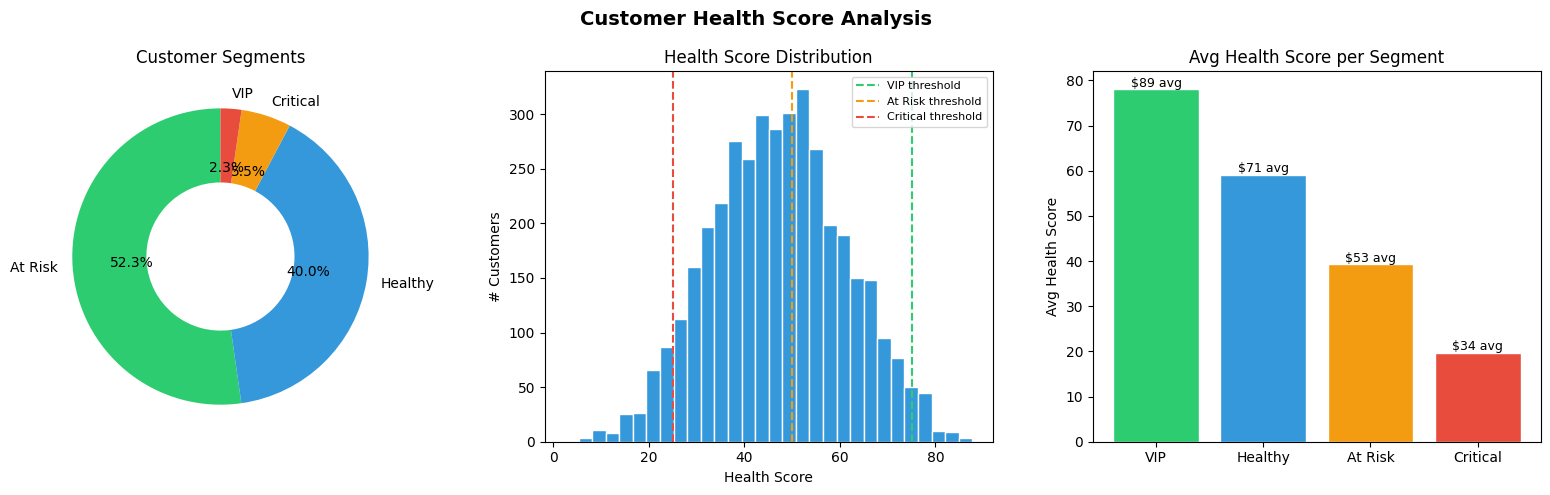

In [33]:
# 5. VISUALIZATIONS

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Customer Health Score Analysis', fontsize=14, fontweight='bold')

# 5a. Segment distribution (donut chart)
seg_counts = customer_df['segment'].value_counts()
colors = ['#2ecc71', '#3498db', '#f39c12', '#e74c3c']  # VIP, Healthy, At Risk, Critical
axes[0].pie(
    seg_counts,
    labels=seg_counts.index,
    autopct='%1.1f%%',
    colors=colors,
    wedgeprops={'width': 0.5},
    startangle=90
)
axes[0].set_title('Customer Segments')

# 5b. Health score distribution
axes[1].hist(customer_df['health_score'], bins=30, color='#3498db', edgecolor='white')
axes[1].axvline(75, color='#2ecc71', linestyle='--', label='VIP threshold')
axes[1].axvline(50, color='#f39c12', linestyle='--', label='At Risk threshold')
axes[1].axvline(25, color='#e74c3c', linestyle='--', label='Critical threshold')
axes[1].set_title('Health Score Distribution')
axes[1].set_xlabel('Health Score')
axes[1].set_ylabel('# Customers')
axes[1].legend(fontsize=8)

# 5c. Avg health score by segment + avg spend
seg_summary = customer_df.groupby('segment').agg(
    avg_health=('health_score', 'mean'),
    avg_spend=('total_spend', 'mean')
).reindex(['VIP', 'Healthy', 'At Risk', 'Critical'])

x = range(len(seg_summary))
bars = axes[2].bar(x, seg_summary['avg_health'], color=colors, edgecolor='white')
axes[2].set_xticks(x)
axes[2].set_xticklabels(seg_summary.index)
axes[2].set_title('Avg Health Score per Segment')
axes[2].set_ylabel('Avg Health Score')
for bar, spend in zip(bars, seg_summary['avg_spend']): # Changed 'total_spend' to 'avg_spend'
    axes[2].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.5,
        f'${spend:.0f} avg',
        ha='center', fontsize=9
    )

plt.tight_layout()
plt.show()

In [34]:
# 6. BUSINESS ACTION MAPPING

action_map = {
    'VIP':      'Exclusive loyalty rewards + early access offers',
    'Healthy':  'Premium membership upsell + cross-sell campaigns',
    'At Risk':  'Re-engagement discounts + personalised recommendations',
    'Critical': 'Win-back campaign + survey to understand churn reasons',
}

print("\n=== Recommended Actions by Segment ===")
for seg, action in action_map.items():
    count = (customer_df['segment'] == seg).sum()
    print(f"  [{seg:8s}] ({count:4d} customers)  →  {action}")


=== Recommended Actions by Segment ===
  [VIP     ] (  89 customers)  →  Exclusive loyalty rewards + early access offers
  [Healthy ] (1560 customers)  →  Premium membership upsell + cross-sell campaigns
  [At Risk ] (2038 customers)  →  Re-engagement discounts + personalised recommendations
  [Critical] ( 213 customers)  →  Win-back campaign + survey to understand churn reasons


## Statistical Summary of `customer_df` Numerical Columns

In [35]:
display(customer_df.describe())

,customer_id,age,total_spend,avg_rating,previous_purchases,discount_usage_pct,score_purchases,score_spend,score_rating,score_subscription,score_discount,health_score
count,3900.000000,3900.000000,3900.000000,3900.000000,3900.000000,3900.000000,3900.000000,3900.000000,3900.000000,3900.000000,3900.000000,3900.000000
mean,1950.500000,44.068462,59.764359,3.750051,25.351538,43.000000,49.697017,49.705449,50.002051,27.000000,57.000000,47.086154
std,1125.977353,15.207589,23.685392,0.713590,14.447125,49.513924,29.483929,29.606740,28.543582,44.401639,49.513924,13.963537
min,1.000000,18.000000,20.000000,2.500000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.500000
25%,975.750000,31.000000,39.000000,3.100000,13.000000,0.000000,24.489796,23.750000,24.000000,0.000000,0.000000,37.275000
50%,1950.500000,44.000000,60.000000,3.800000,25.000000,0.000000,48.979592,50.000000,52.000000,0.000000,100.000000,47.200000
75%,2925.250000,57.000000,81.000000,4.400000,38.000000,100.000000,75.510204,76.250000,76.000000,100.000000,100.000000,56.400000
max,3900.000000,70.000000,100.000000,5.000000,50.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,87.700000
